<a href="https://colab.research.google.com/github/AeternaGlor/house_prices_prediction/blob/main/house_prices_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# from google.colab import drive
# drive.mount('/gdrive')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/House Prices/test.csv")
train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/House Prices/train.csv")
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
train_df[['OverallQual', 'OverallCond']].corr()

,OverallQual,OverallCond
OverallQual,1.000000,-0.091932
OverallCond,-0.091932,1.000000


In [ ]:
train_df[['YearBuilt', 'YearRemodAdd']].corr()

,YearBuilt,YearRemodAdd
YearBuilt,1.000000,0.592855
YearRemodAdd,0.592855,1.000000


In [ ]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Анализ и предобработка данных

### Заполнение пропусков

In [ ]:
data = train_df.isna().sum()
data = data[data > 0]
data

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


Как видно, в большинстве столбцов процент пропусков мал (меньше 6%), а значит данные записи можно просто удалить

In [ ]:
# 85 - это примерно 6 процентов от 1460 - числа записей в train
data_to_drop = data[(data > 0) & (data < 85)]
col_to_drop = data_to_drop.index
train_df.dropna(subset=col_to_drop, inplace=True)

data = train_df.isna().sum()
data = data[data > 0]
data

,0
LotFrontage,244
Alley,1257
MasVnrType,763
FireplaceQu,591
PoolQC,1331
Fence,1077
MiscFeature,1289


Согласно описанию данных, в данных категориальных признаках пропуск означает отсутствие у дома соответствующего атрибута. Поэтому пропуски были отнесены в отдельную категорию 'None'


При этом пропуски в атрибуте LotFrontage были заполнены медианой

In [ ]:
from sklearn.impute import SimpleImputer

none_cols = [
    'Alley',
    'MasVnrType',
    'FireplaceQu',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

cat_imputer = SimpleImputer(strategy='constant', fill_value='None')
train_df[none_cols] = cat_imputer.fit_transform(train_df[none_cols])

lot_frontage_imputer = SimpleImputer(strategy='median')
train_df['LotFrontage'] = lot_frontage_imputer.fit_transform(train_df[['LotFrontage']])

In [ ]:
train_df.isna().sum().sum()

np.int64(0)

In [ ]:
train_df.duplicated().sum()

np.int64(0)

### Работа с числовыми признаками

На основе информации описания столбцов из файла data_description.txt признаки были разделены на числовые и категориальные. В категориальных также было выделено подмножество порядковых признаков, т.к. для их кодирования должен корошо подойти label-encoding, в то время как для других категориальных будет использовано one-hot кодирование

In [ ]:
# numerical_columns = [col for col in df.columns if df[col].dtype != 'O']
catagorical_columns = [
    'MSSubClass',
    'OverallQual',
    'OverallCond',
    'MSZoning',
    'Street',
    'Alley',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'ExterQual',
    'ExterCond',
    'Foundation',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'Heating',
    'HeatingQC',
    'CentralAir',
    'Electrical',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PavedDrive',
    'PoolQC',
    'Fence',
    'MiscFeature',
    'SaleType',
    'SaleCondition'
]

ordinal_columns = [
    'OverallQual',
    'OverallCond',
    'Utilities',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
]

numerical_columns = [
    'LotFrontage',
    'LotArea',
    'YearBuilt',
    'YearRemodAdd',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'LowQualFinSF',
    'GrLivArea',
    'BsmtFullBath',
    'BsmtHalfBath',
    'FullBath',
    'HalfBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'EnclosedPorch',
    '3SsnPorch',
    'ScreenPorch',
    'PoolArea',
    'MiscVal',
    'MoSold',
    'YrSold',
    'SalePrice'
 ]

In [ ]:
print(len(catagorical_columns))
print(len(ordinal_columns))
print(len(numerical_columns))


46
19
34


**Data fields**

* **SalePrice - the property's sale price in dollars. This is the target variable** that you're trying to predict.
* **MSSubClass**: The building class
* **MSZoning**: The general zoning classification
* LotFrontage: Linear feet of street connected to property
* **LotArea**: Lot size in square feet
* Street: Type of road access
* Alley: Type of alley access
* LotShape: General shape of property
* LandContour: Flatness of the property
* **Utilities**: Type of utilities available
* LotConfig: Lot configuration
* LandSlope: Slope of property
* Neighborhood: Physical locations within Ames city limits
* Condition1: Proximity to main road or railroad
* Condition2: Proximity to main road or railroad (if a second is present)
* **BldgType**: Type of dwelling
* **HouseStyle**: Style of dwelling
* **OverallQual**: Overall material and finish quality
* **OverallCond**: Overall condition rating
* **YearBuilt**: Original construction date
* **YearRemodAdd**: Remodel date **(same as construction date if no remodeling or additions)** - этим объясняется их высокая корреляция
* RoofStyle: Type of roof
* RoofMatl: Roof material
* Exterior1st: Exterior covering on house
* Exterior2nd: Exterior covering on house (if more than one material)
* MasVnrType: Masonry veneer type
* MasVnrArea: Masonry veneer area in square feet
* ExterQual: Exterior material quality
* ExterCond: Present condition of the material on the exterior
* Foundation: Type of foundation
* BsmtQual: Height of the basement
* BsmtCond: General condition of the basement
* BsmtExposure: Walkout or garden level basement walls
* BsmtFinType1: Quality of basement finished area
* BsmtFinSF1: Type 1 finished square feet
* BsmtFinType2: Quality of second finished area (if present)
BsmtFinSF2: Type 2 finished square feet
BsmtUnfSF: Unfinished square feet of basement area
TotalBsmtSF: Total square feet of basement area
Heating: Type of heating
HeatingQC: Heating quality and condition
CentralAir: Central air conditioning
Electrical: Electrical system
* 1stFlrSF: First Floor square feet
* 2ndFlrSF: Second floor square feet
* LowQualFinSF: Low quality finished square feet (all floors)
* GrLivArea: Above grade (ground) living area square feet
BsmtFullBath: Basement full bathrooms
BsmtHalfBath: Basement half bathrooms
FullBath: Full bathrooms above grade
HalfBath: Half baths above grade
Bedroom: Number of bedrooms above basement level
Kitchen: Number of kitchens
KitchenQual: Kitchen quality
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
Functional: Home functionality rating
Fireplaces: Number of fireplaces
FireplaceQu: Fireplace quality
GarageType: Garage location
GarageYrBlt: Year garage was built
GarageFinish: Interior finish of the garage
GarageCars: Size of garage in car capacity
GarageArea: Size of garage in square feet
GarageQual: Garage quality
GarageCond: Garage condition
PavedDrive: Paved driveway
WoodDeckSF: Wood deck area in square feet
OpenPorchSF: Open porch area in square feet
EnclosedPorch: Enclosed porch area in square feet
3SsnPorch: Three season porch area in square feet
ScreenPorch: Screen porch area in square feet
PoolArea: Pool area in square feet
PoolQC: Pool quality
Fence: Fence quality
MiscFeature: Miscellaneous feature not covered in other categories
MiscVal: $Value of miscellaneous feature
MoSold: Month Sold
YrSold: Year Sold
SaleType: Type of sale
SaleCondition: Condition of sale




In [ ]:
train_df[numerical_columns].describe()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,...,1338.000000,1338.000000,1338.000000,1338.000000,1338.00000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,70.621076,10706.294469,1973.029148,1985.668909,110.360239,464.234679,49.218236,582.494768,1095.947683,1176.221973,...,99.384903,47.782511,21.263827,3.585949,16.43423,3.010463,42.932735,6.331839,2007.805680,186761.782511
std,22.161826,10336.621126,29.563540,20.296463,185.604816,458.792420,166.196584,439.950528,405.554435,386.644986,...,127.537065,65.362562,60.843964,30.224622,58.05159,41.961337,508.056255,2.699437,1.330691,78913.847668
min,21.000000,1300.000000,1880.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,105.000000,438.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,2006.000000,35311.000000
25%,60.000000,7744.000000,1956.000000,1968.000000,0.000000,0.000000,0.000000,248.000000,819.750000,894.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,2007.000000,135000.000000
50%,70.000000,9600.000000,1976.000000,1994.500000,0.000000,413.000000,0.000000,489.000000,1021.500000,1098.000000,...,6.000000,28.000000,0.000000,0.000000,0.00000,0.000000,0.000000,6.000000,2008.000000,168500.000000
75%,80.000000,11760.750000,2001.000000,2004.000000,174.000000,733.000000,0.000000,815.750000,1324.000000,1414.000000,...,174.500000,70.000000,0.000000,0.000000,0.00000,0.000000,0.000000,8.000000,2009.000000,220000.000000
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,...,857.000000,547.000000,552.000000,508.000000,480.00000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


array([[<Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>],
       [<Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>],
       [<Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'BedroomAbvGr'}>],
       [<Axes: title={'center': 'KitchenAbvGr'}>,
        <Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'Fi

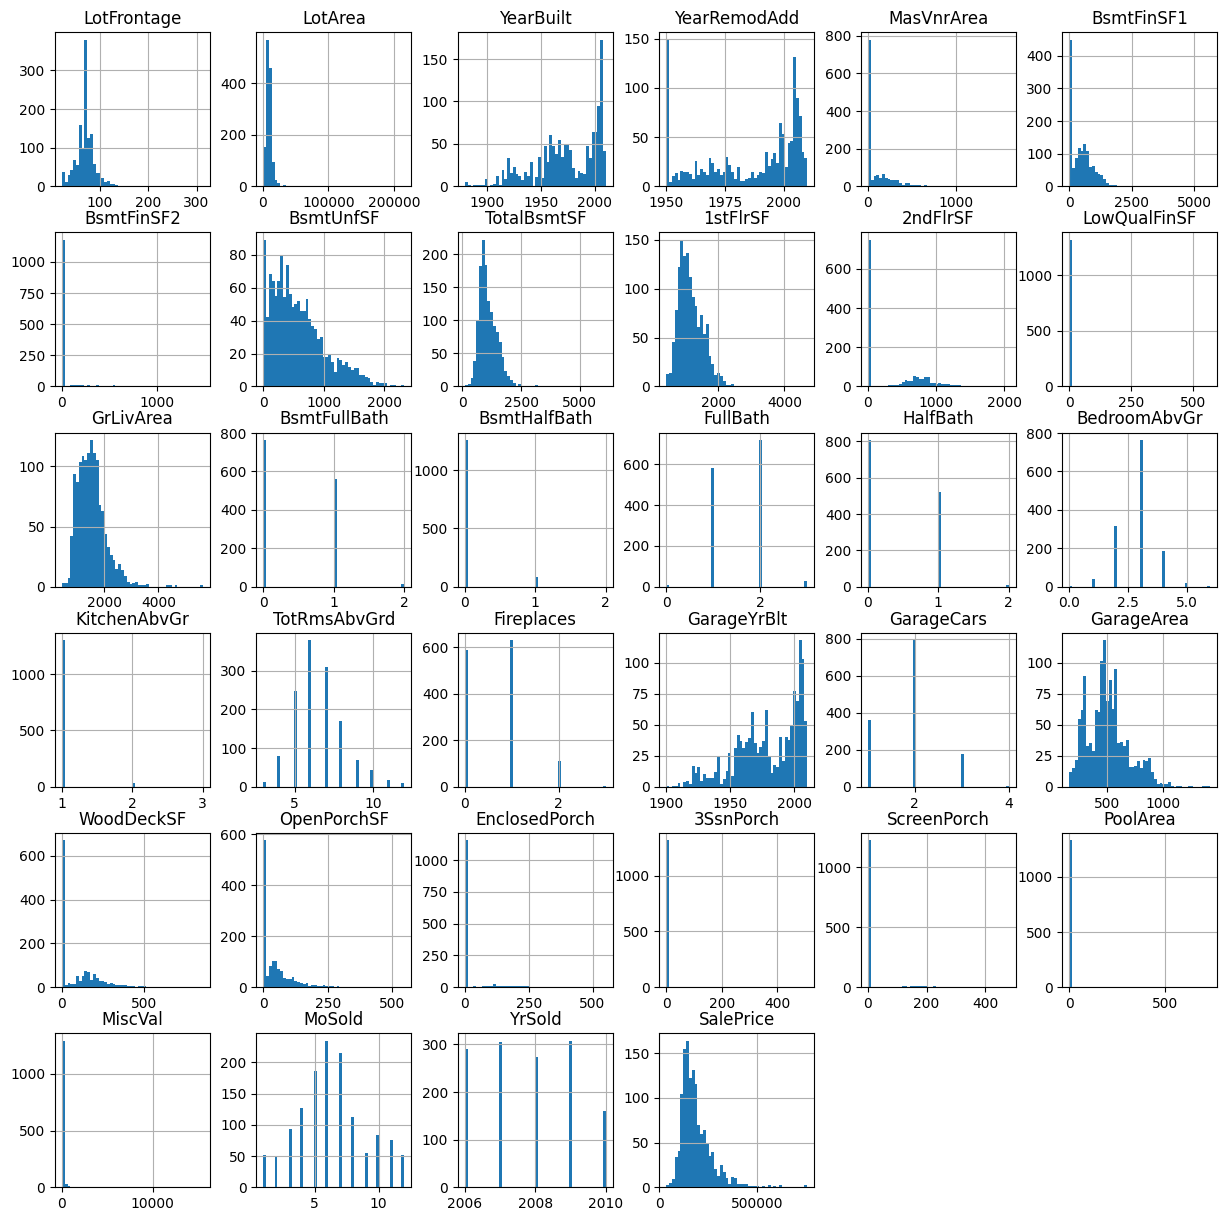

In [ ]:
train_df[numerical_columns].hist(figsize=(15, 15), bins=50,)

Как видно, распределения почти всех числовых признаков несбалансированы и далеки от нормального

In [ ]:
import seaborn as sns

<Axes: >

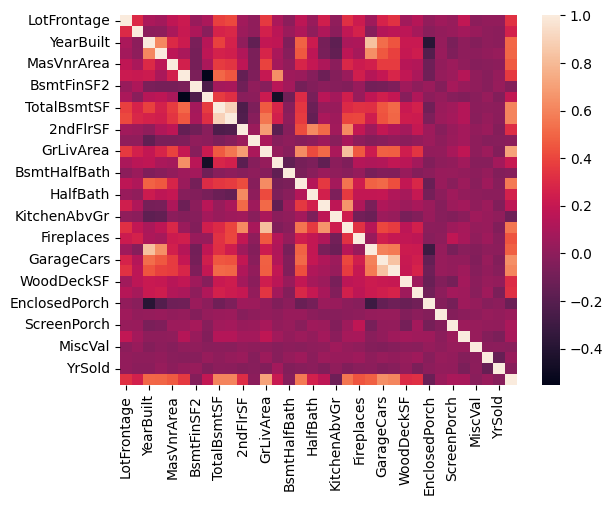

In [ ]:
corrmat = train_df[numerical_columns].corr()
sns.heatmap(corrmat)

In [ ]:
corrmat[abs(corrmat) > 0.5]

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
LotFrontage,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotArea,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearBuilt,NaN,NaN,1.000000,0.617156,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.504297
YearRemodAdd,NaN,NaN,0.617156,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.501435
MasVnrArea,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,-0.552809,0.505000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BsmtFinSF2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BsmtUnfSF,NaN,NaN,NaN,NaN,NaN,-0.552809,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,NaN,NaN,NaN,NaN,NaN,0.505000,NaN,NaN,1.000000,0.893110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.602042
1stFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.893110,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.604714


Было замечено, что в данных присутствуют большие корреляции. Для более наглядного отображения были выбраны лишь пары признаков с абсолютной корреляцией выше 0,5

Также было замечено, что целевая переменная SalePtice заметно коррелирует со многими из этих признаков

<Axes: >

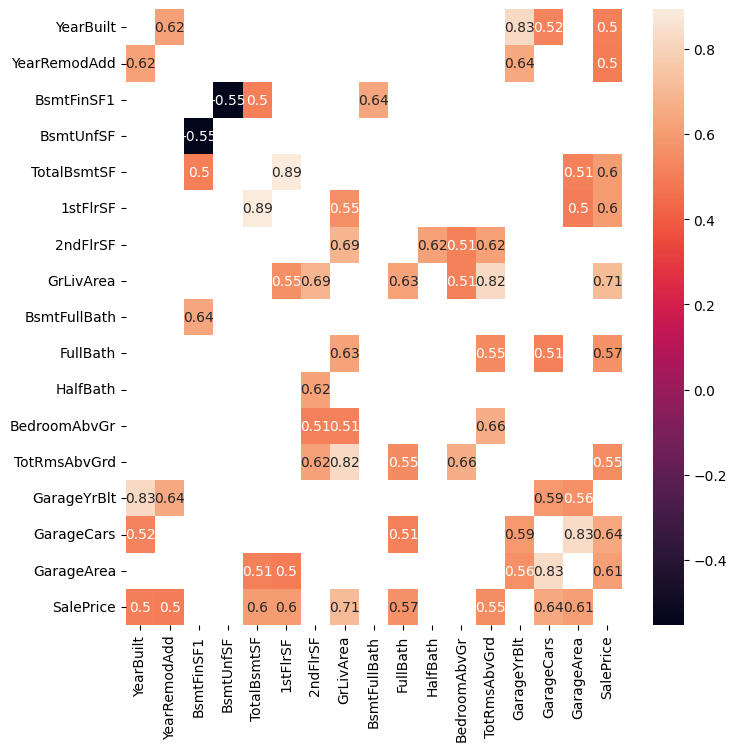

In [ ]:
import numpy as np


high_corr_mat = corrmat.where(abs(corrmat) > 0.5)
np.fill_diagonal(high_corr_mat.values, np.nan)
high_corr_mat = high_corr_mat.dropna(axis=0, how='all')
high_corr_mat = high_corr_mat.dropna(axis=1, how='all')
high_corr_mat.fillna(0)

plt.figure(figsize=(8, 8))
sns.heatmap(high_corr_mat, annot=True)

На первом этапе было решено просто удалить по одному признаку из пар, чья корреляция превышает 0.7

In [ ]:
train_df = train_df.drop(columns=['GarageCars', 'GarageYrBlt', 'TotRmsAbvGrd',  'TotalBsmtSF'])

### Работа с категориальными признаками

In [ ]:
train_df[catagorical_columns].nunique()

,0
MSSubClass,15
OverallQual,9
OverallCond,8
MSZoning,5
Street,2
Alley,3
LotShape,4
LandContour,4
Utilities,2
LotConfig,5


In [ ]:
not_ordinal_cat_columns = [col for col in catagorical_columns if col not in ordinal_columns]
train_df[not_ordinal_cat_columns].nunique()

,0
MSSubClass,15
MSZoning,5
Street,2
Alley,3
LotShape,4
LandContour,4
LotConfig,5
LandSlope,3
Neighborhood,25
Condition1,9


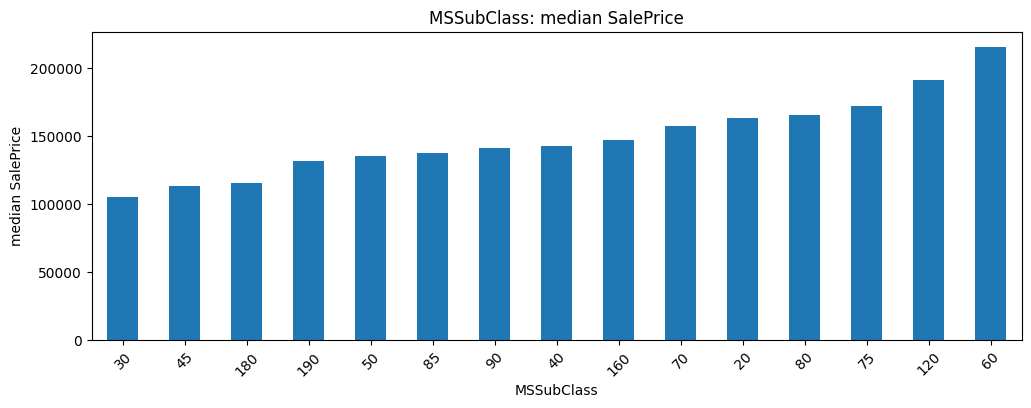

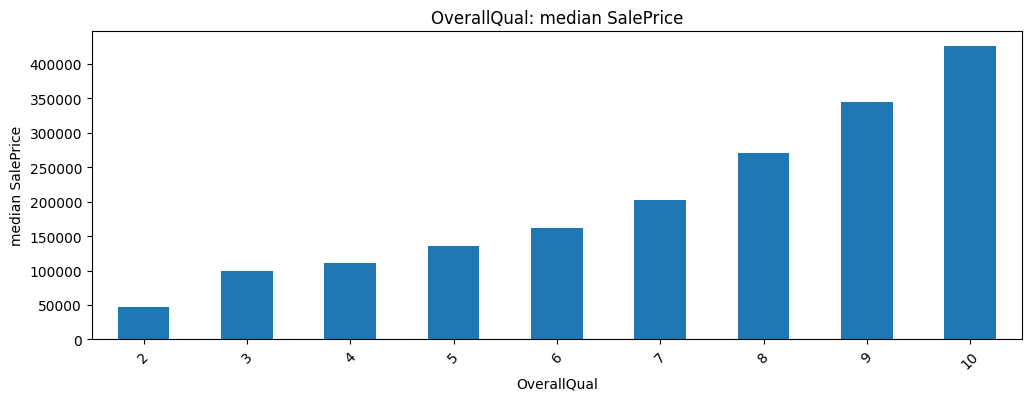

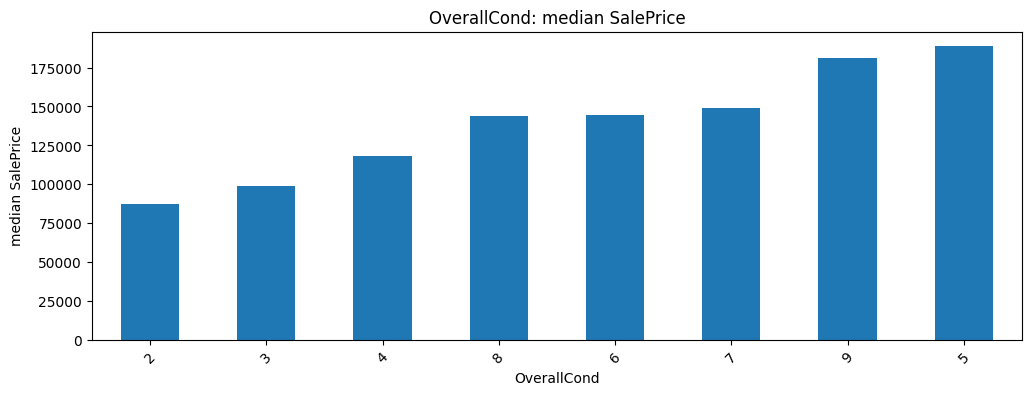

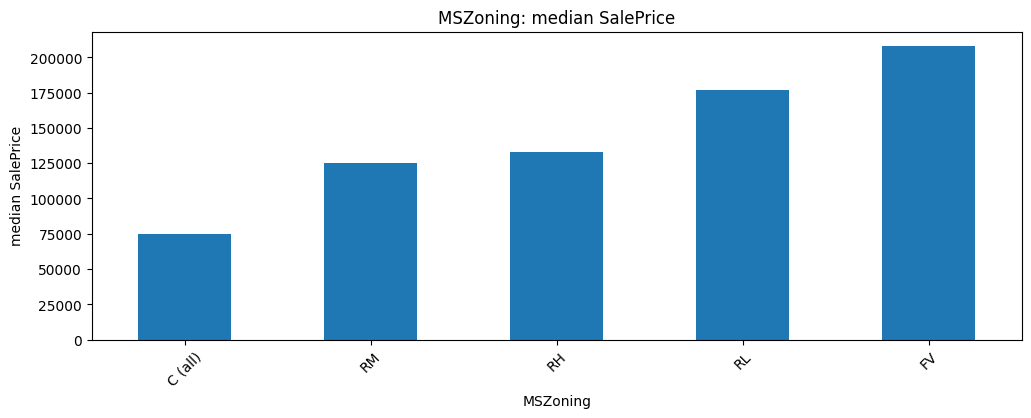

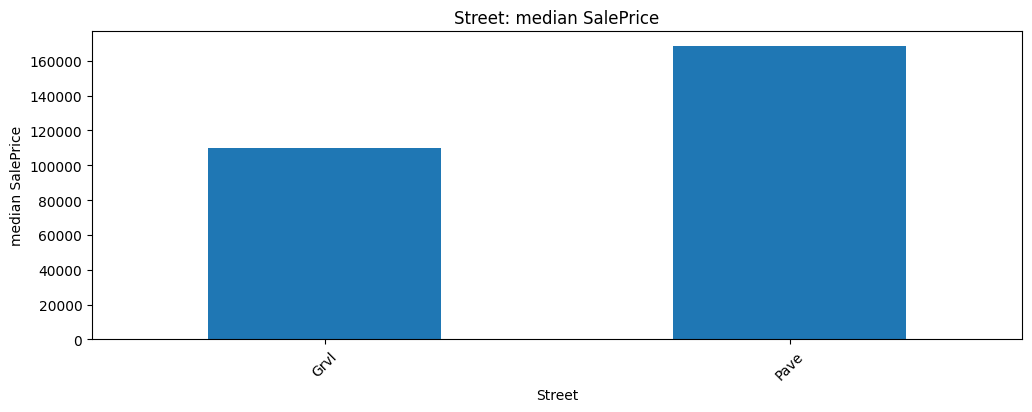

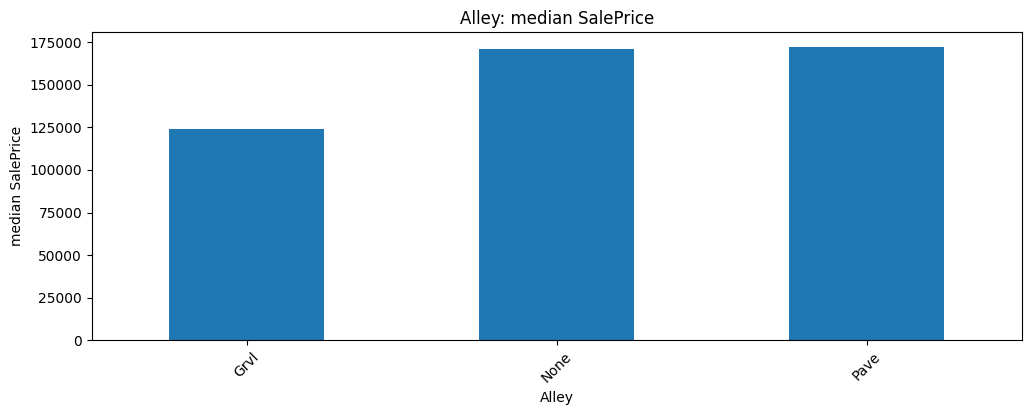

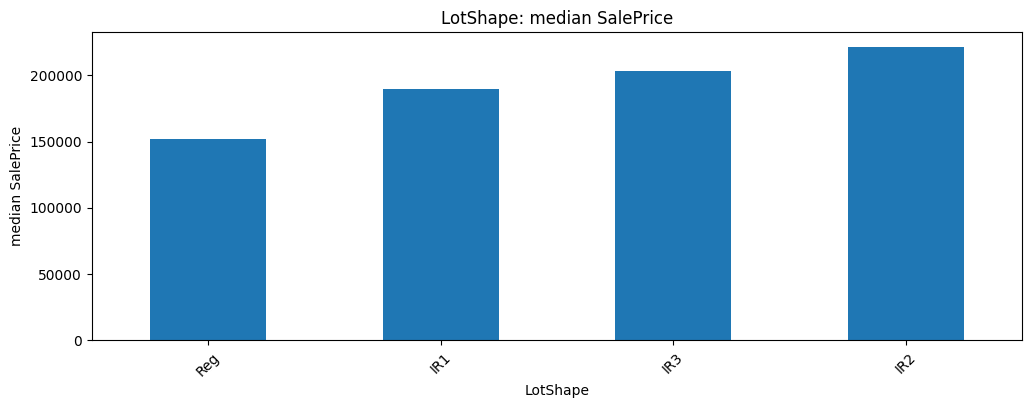

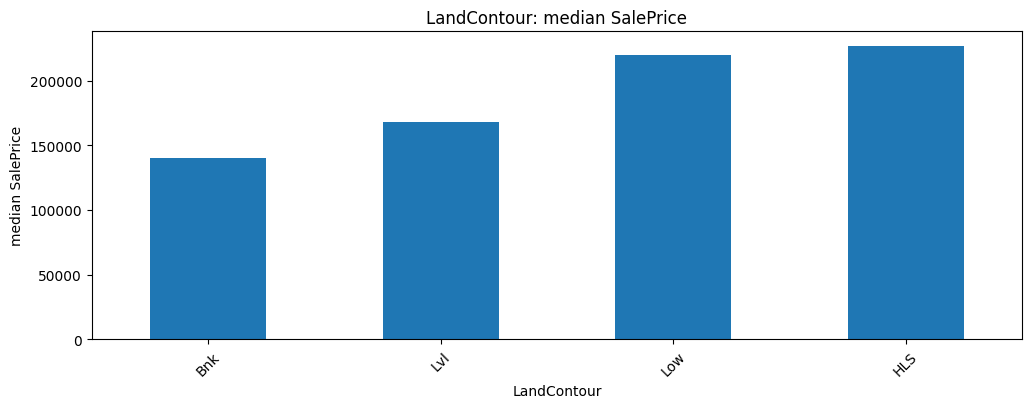

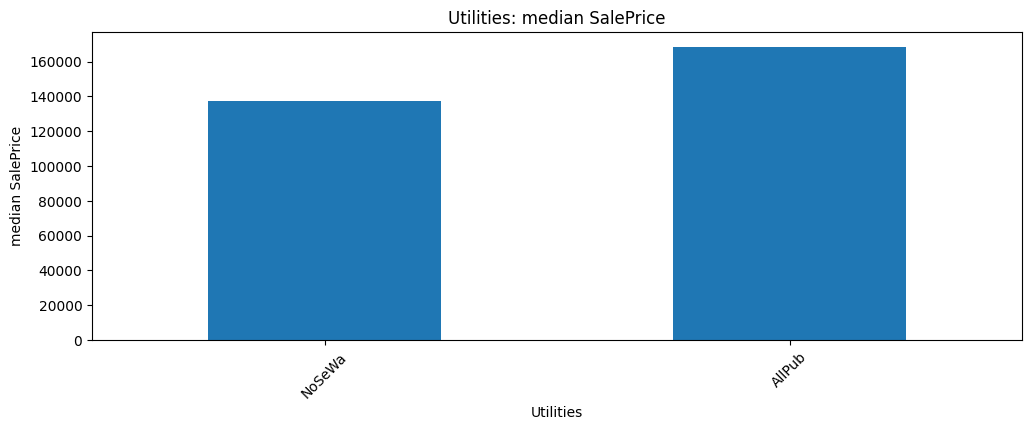

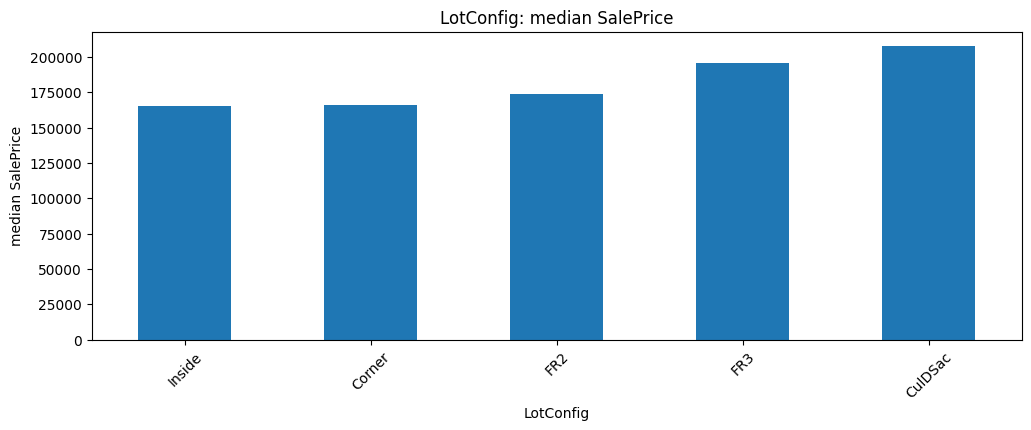

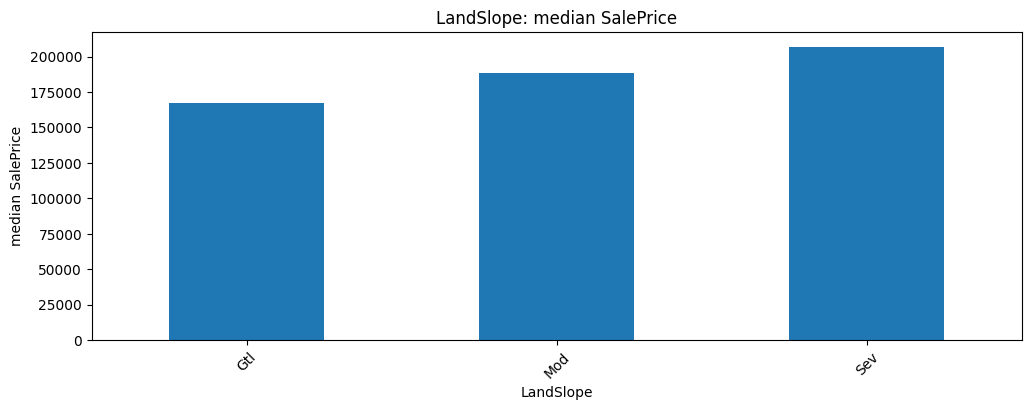

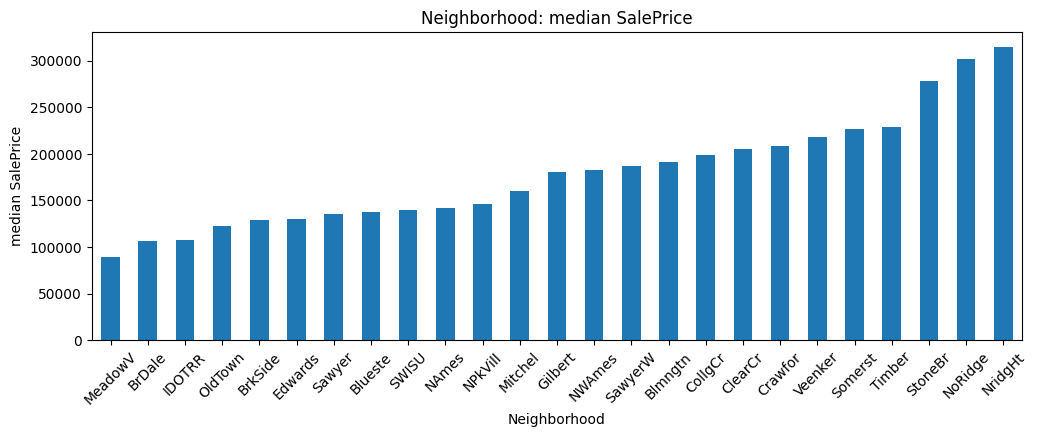

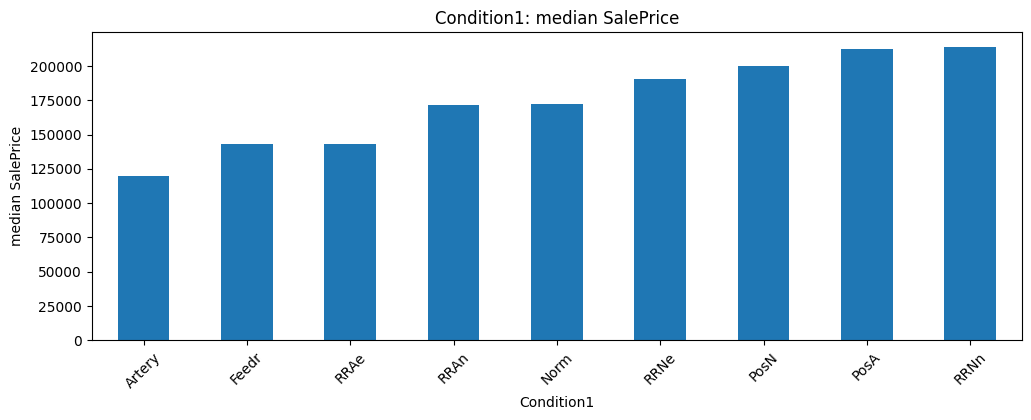

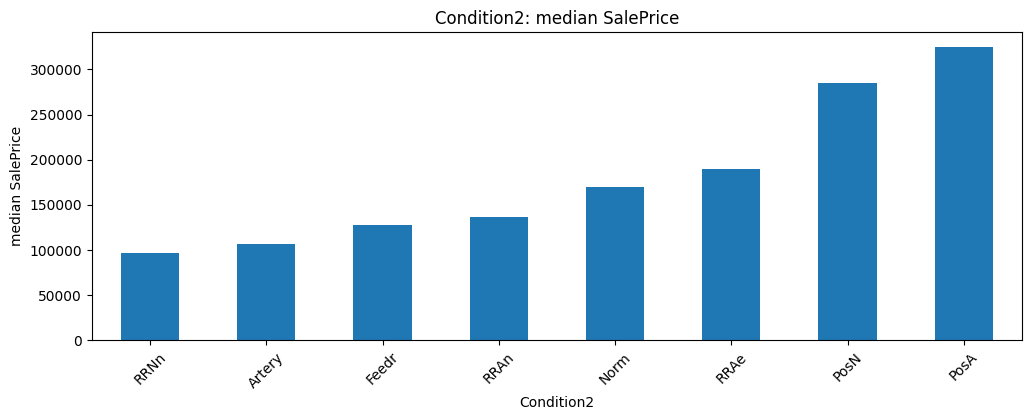

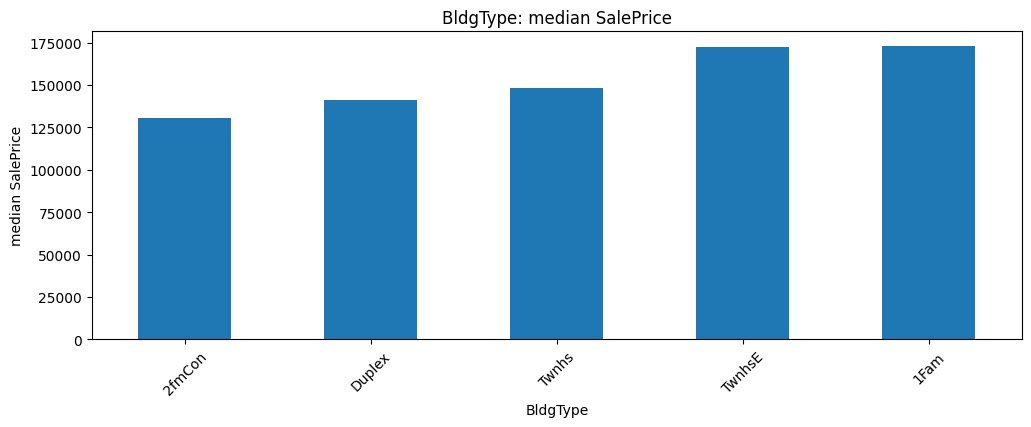

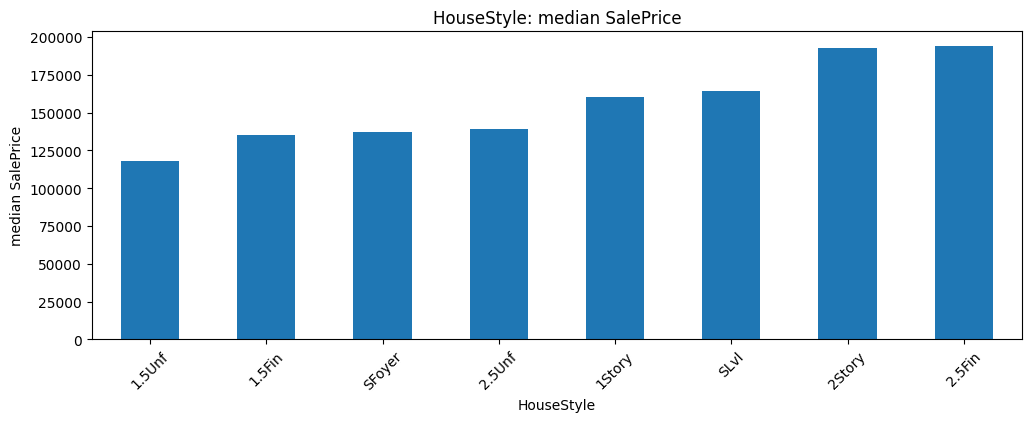

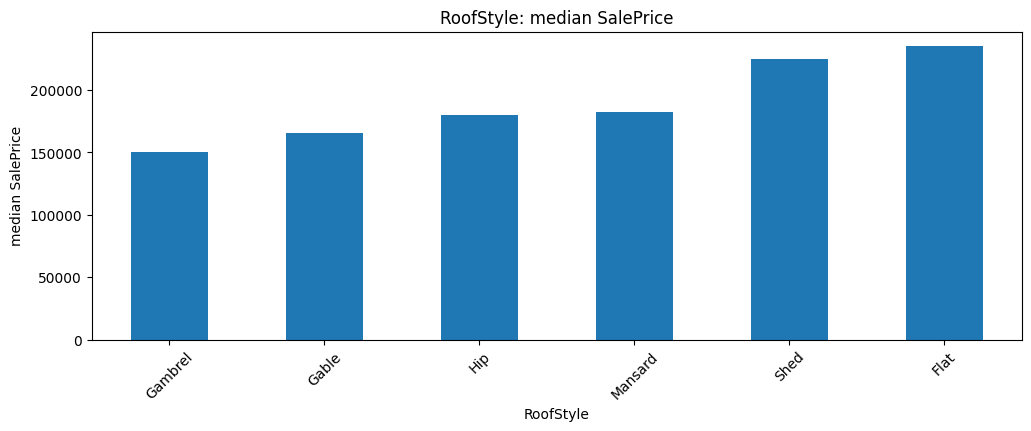

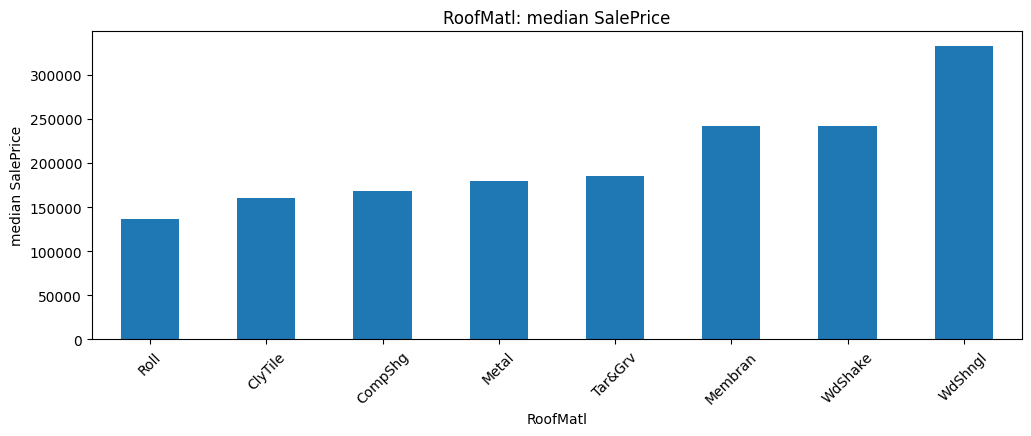

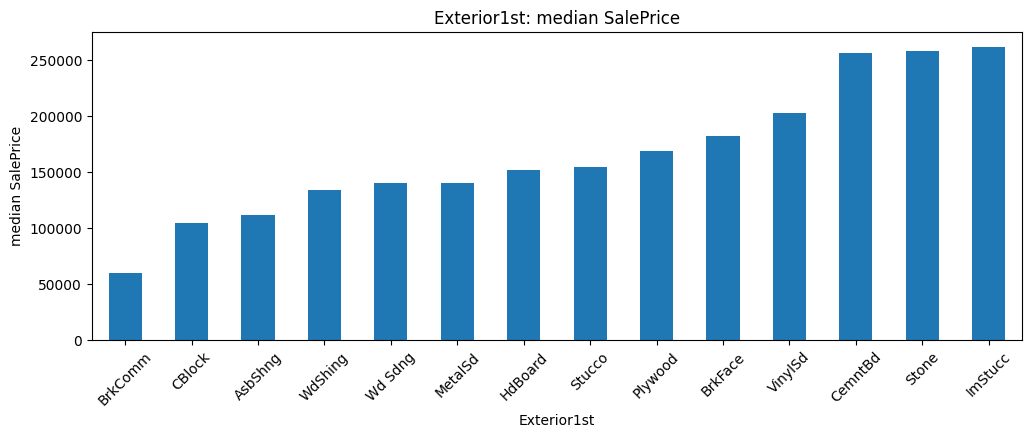

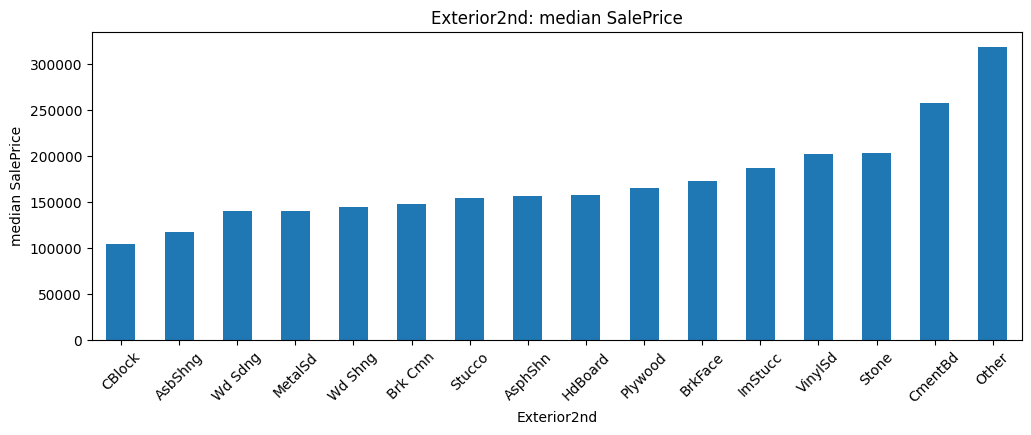

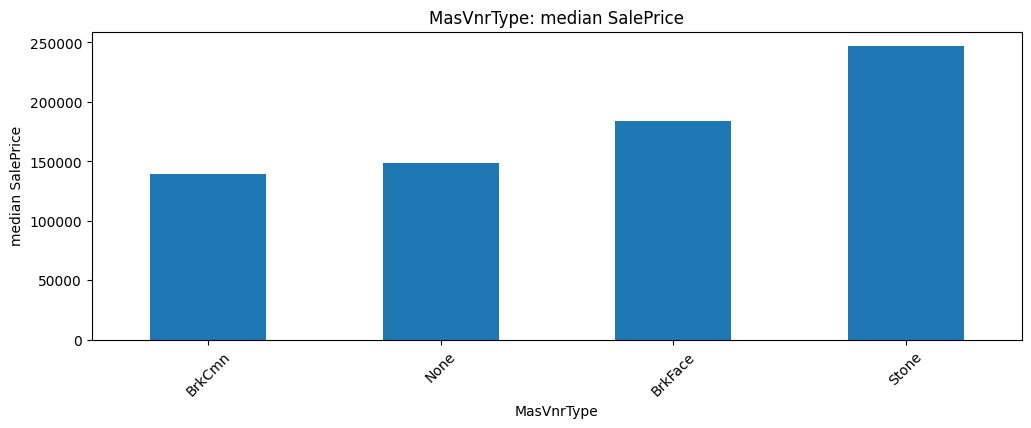

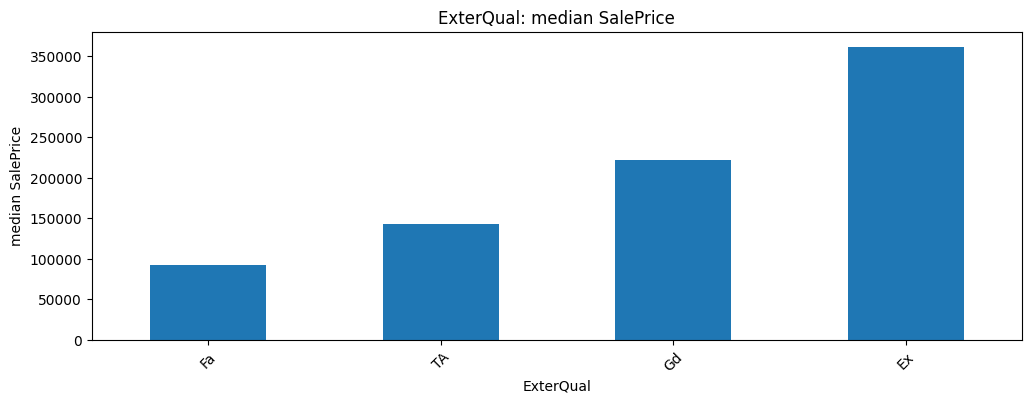

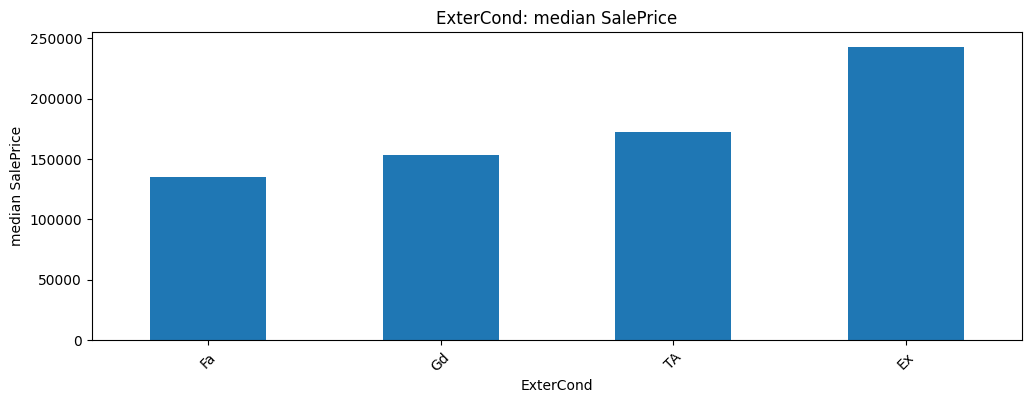

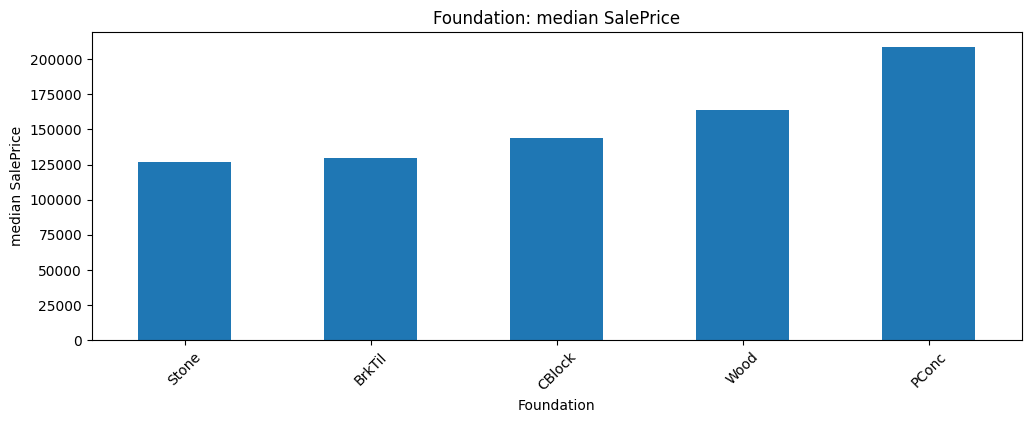

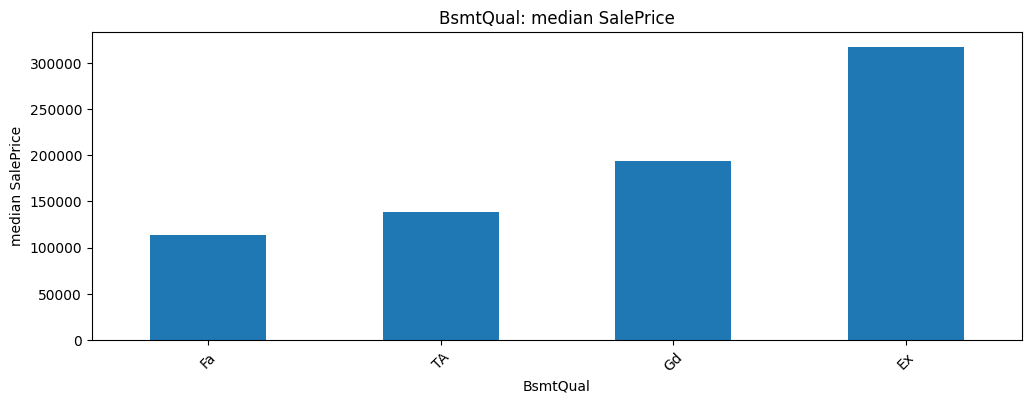

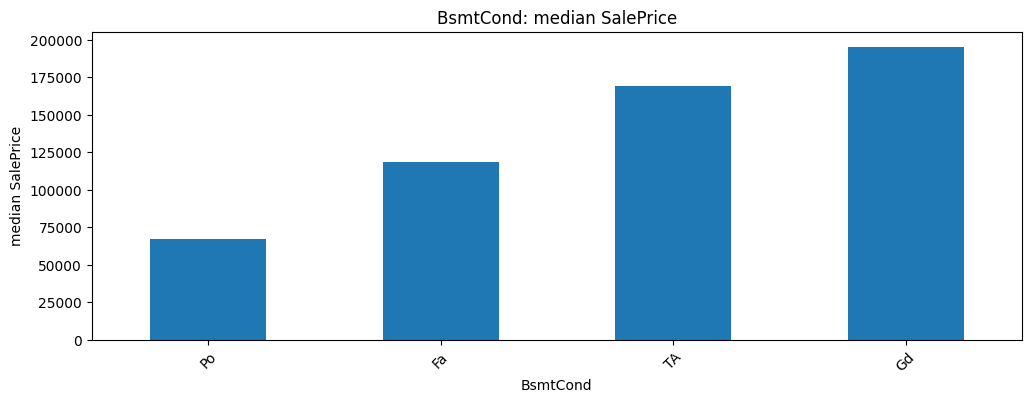

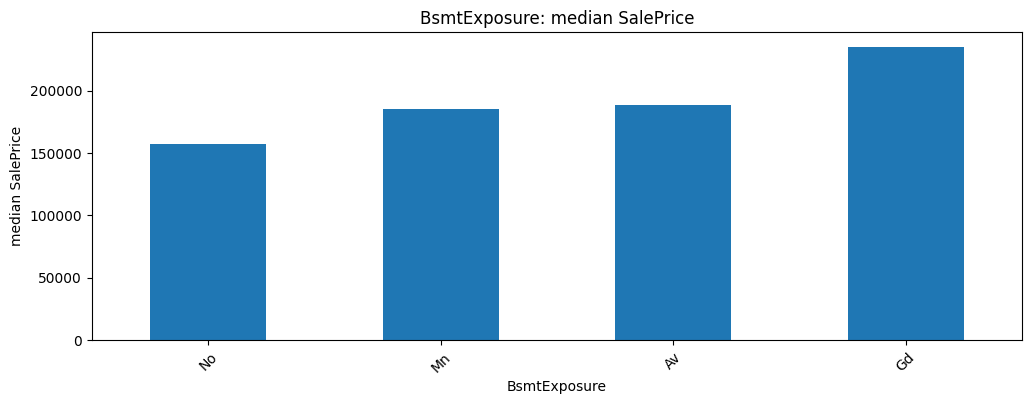

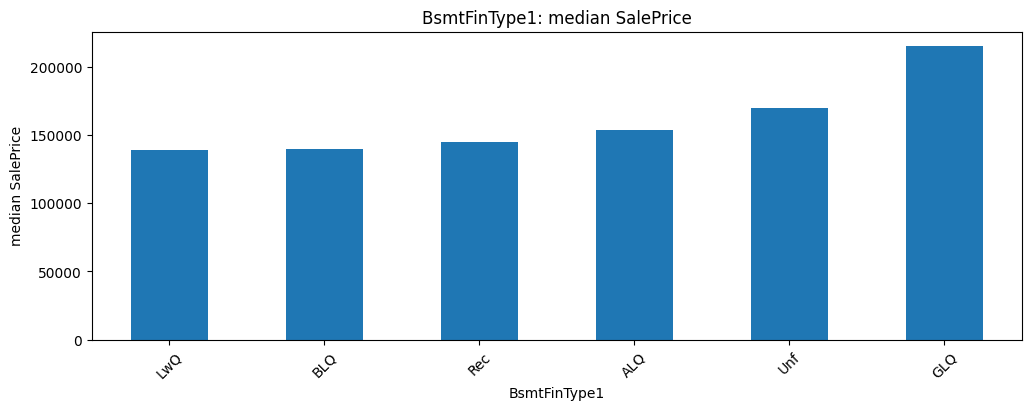

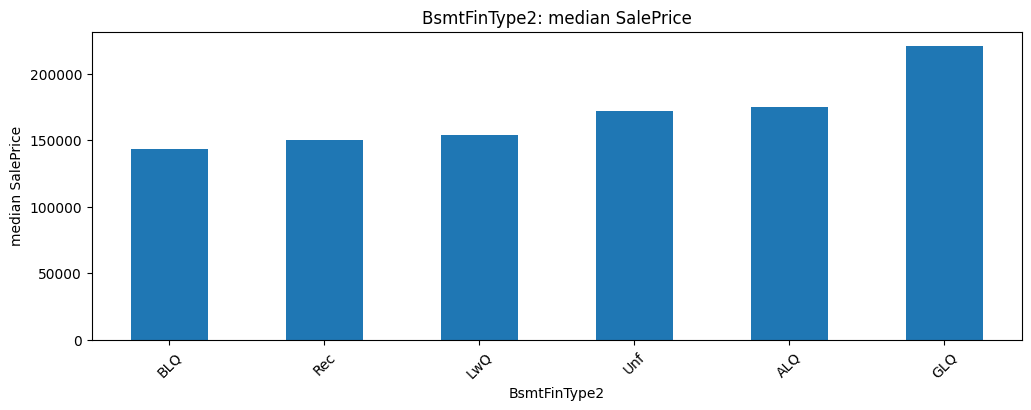

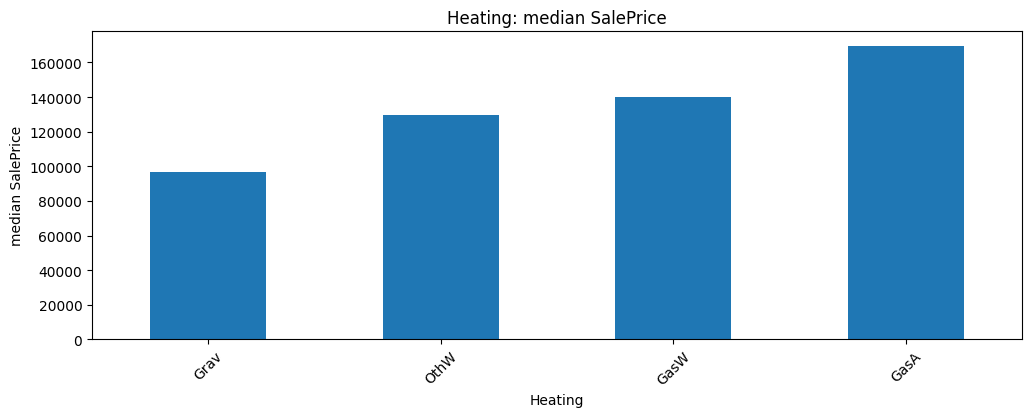

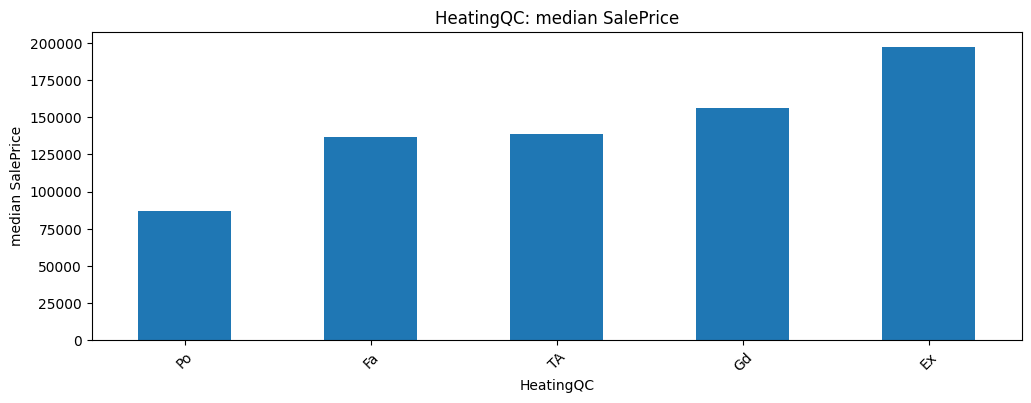

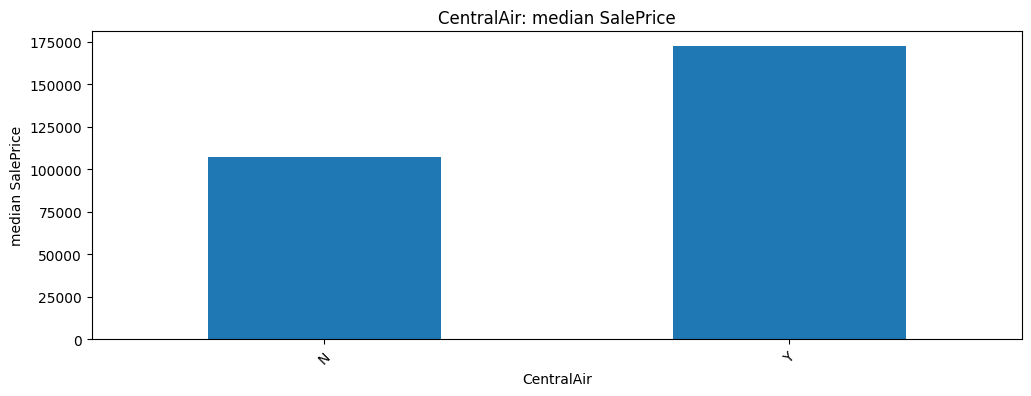

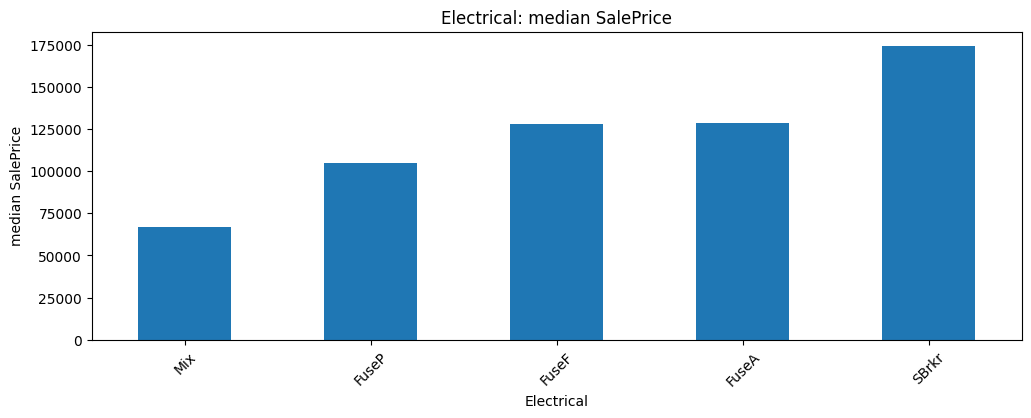

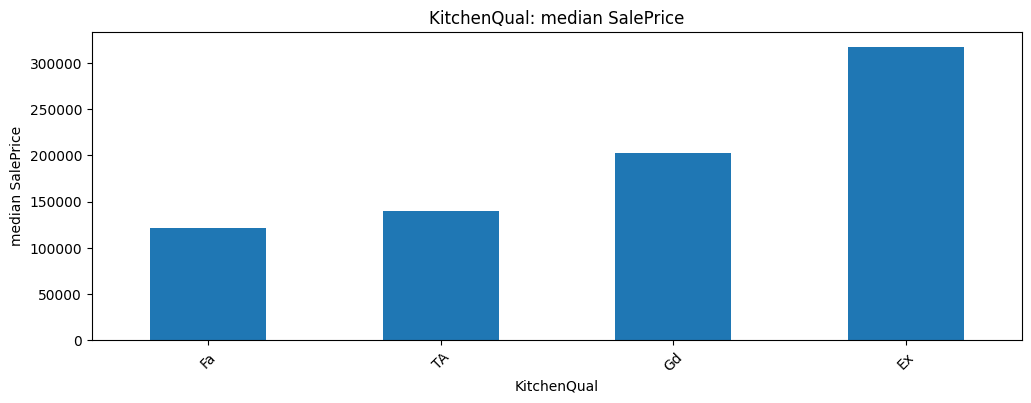

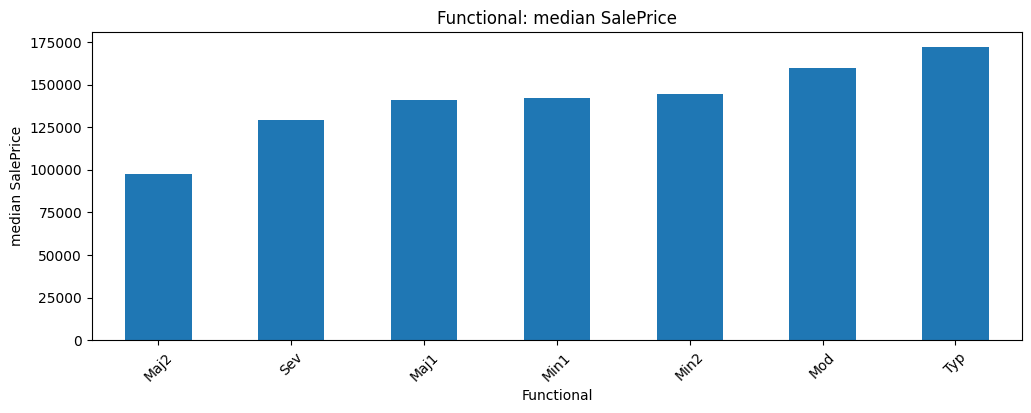

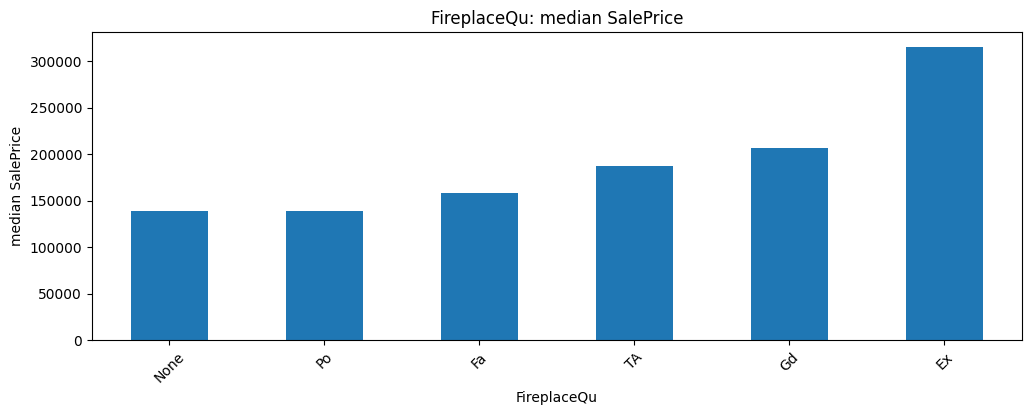

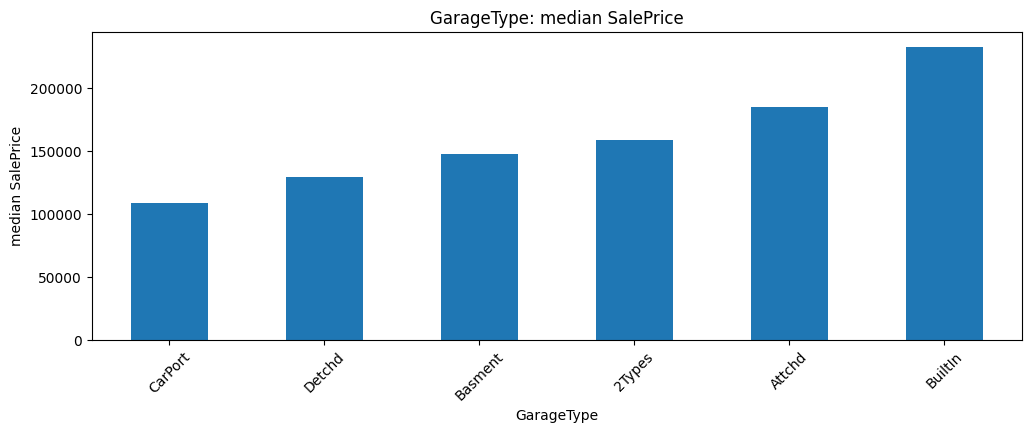

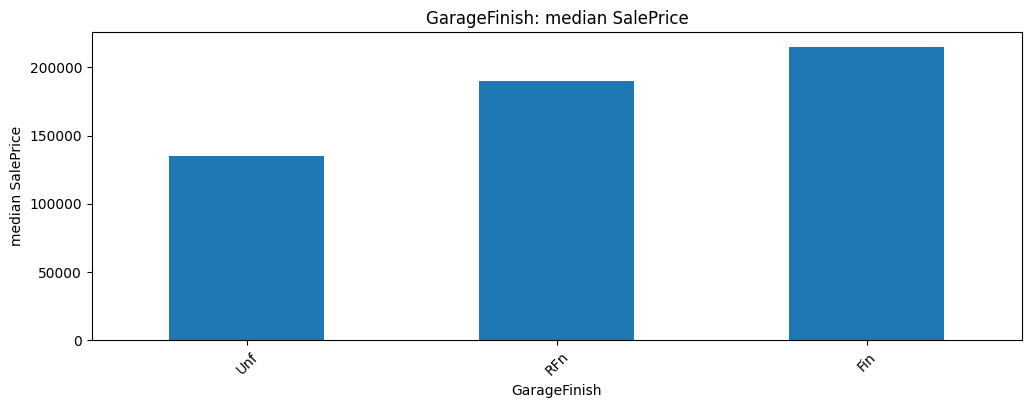

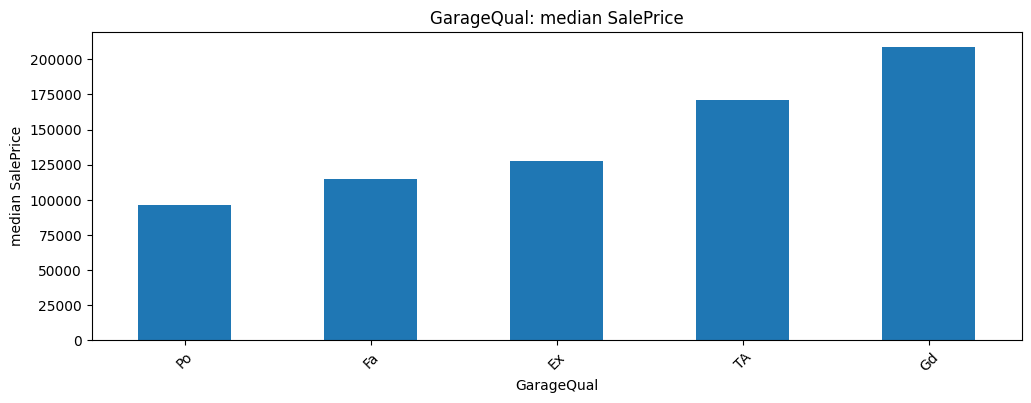

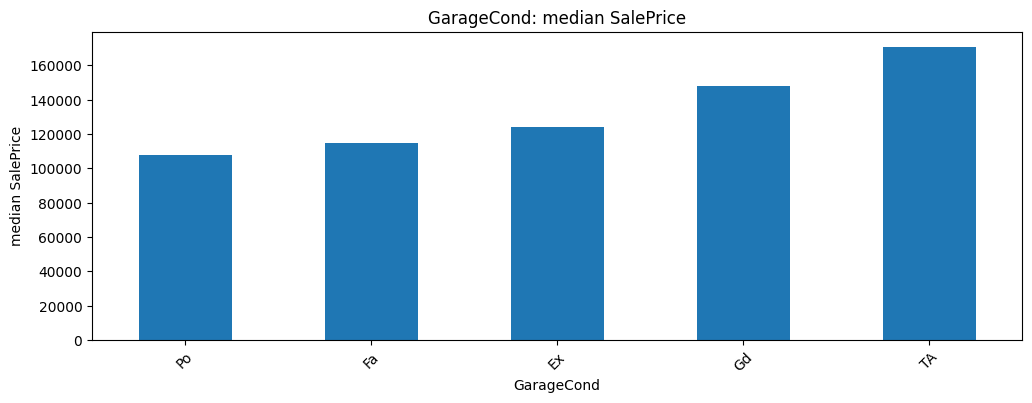

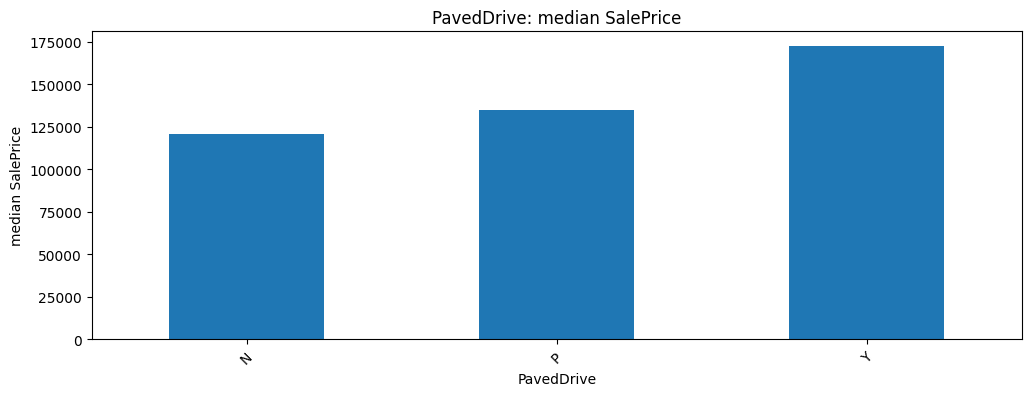

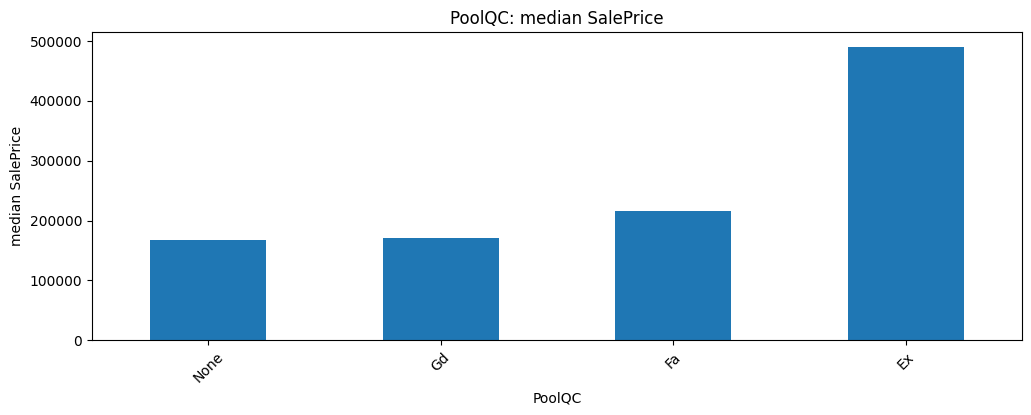

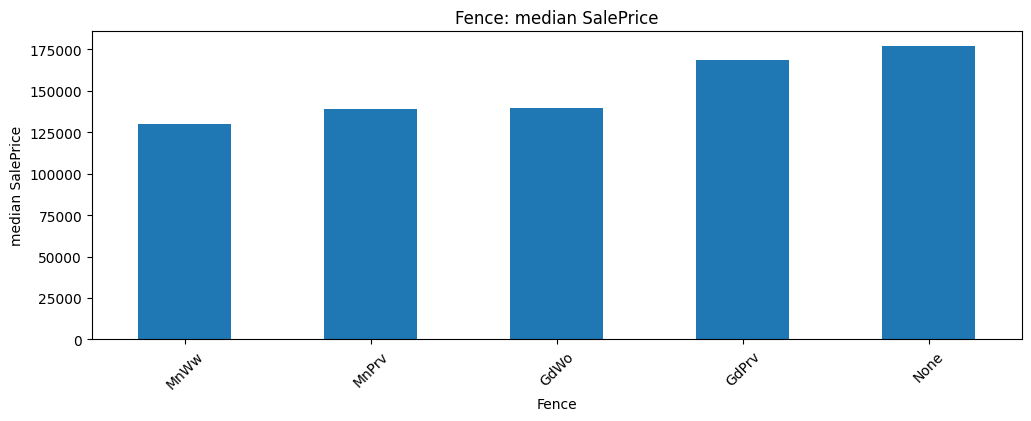

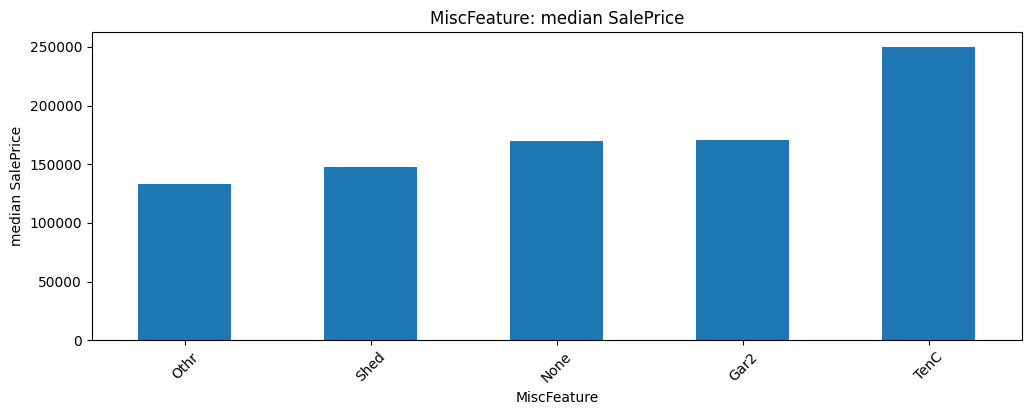

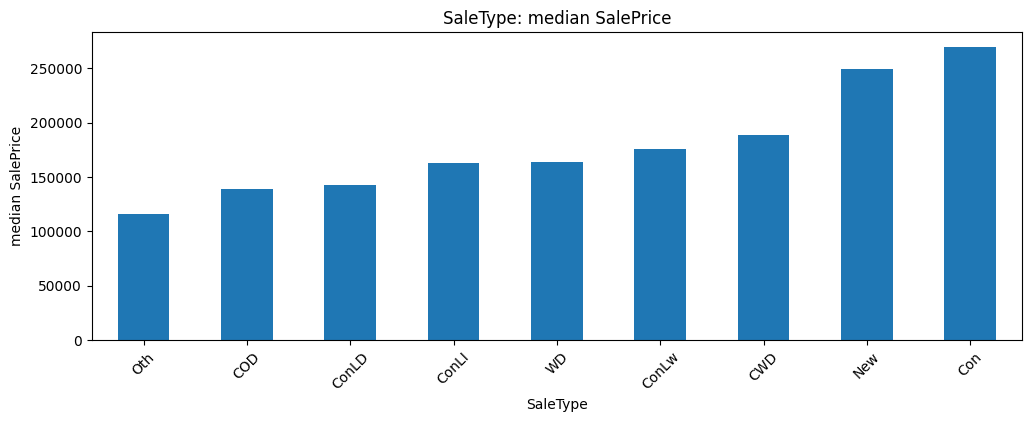

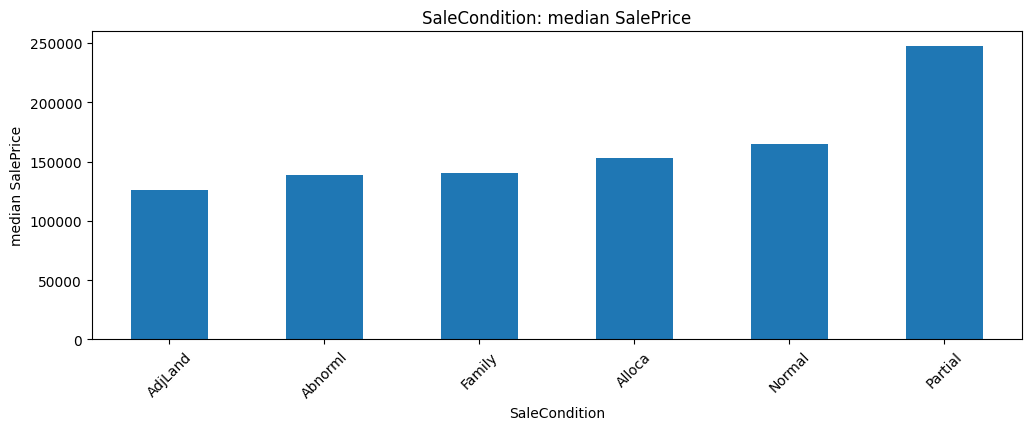

In [ ]:
def watch_distribution(column):
  plt.figure(figsize=(12, 4))
  train_df.groupby(column)['SalePrice'].median().sort_values().plot(kind='bar', figsize=(12, 4))
  plt.title(f'{column}: median SalePrice')
  plt.ylabel('median SalePrice')
  plt.xticks(rotation=45)
  plt.show()

for column in catagorical_columns:
  watch_distribution(column)


Можно заметить, что некоторые признаки показывают заметно бОльшую связь с целевой переменной, чем другие. Например выделяются такие признкаки как OverallQual, Neighborhood, ExterQual.


На основе этого можно предположить, что эти признаки являются довольно сильными с точки зрения предсказания стоимости дома

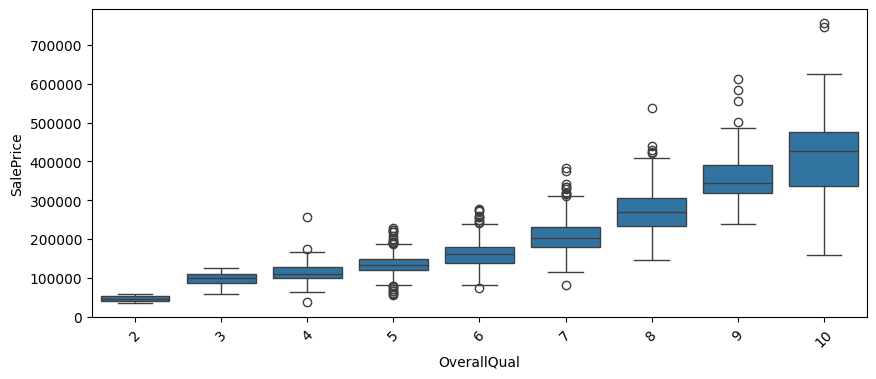

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df)
plt.xticks(rotation=45)
plt.show()

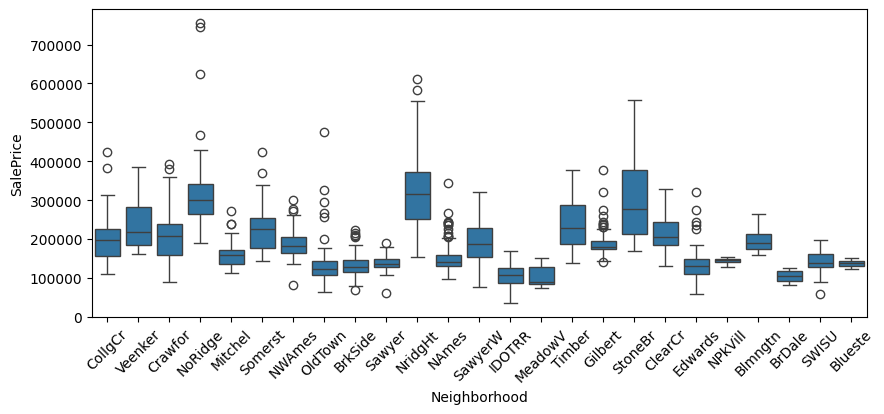

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train_df)
plt.xticks(rotation=45)
plt.show()

#### Цифровизация (кодирование) категориальных признаков

Категориальные фичи были закодированы двумя способами:
1) всё с помощью onehot
2) порядковые категориальные закодированы с помощью ordinal encoding, остальные - onehot

Затем было сравнено качество работы моделей для в зависимости от способа кодирования

#### Разделение (тренировочных) данных на train и test

До кодирования было произведено разделение данных та тренировочную и тестовую части. Таким образом, для разных способов кодирования модель будет обучатся и тестироваться на одинаковых наборах записей.

In [ ]:
from sklearn.model_selection import train_test_split

train_df = train_df.drop('Id', axis=1)
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### OneHotEncoder ко всем признакам

In [ ]:
# первая стратегия - применить OneHotEncoder ко всем признакам
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_encoded = ohe.fit_transform(X_train[catagorical_columns])

In [ ]:
ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
ohe_df

,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
610,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1402,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
530,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1413,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
933,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_train_ohe = pd.concat([X_train, ohe_df], axis=1)
X_train_ohe = X_train_ohe.drop(catagorical_columns, axis=1)
X_train_ohe

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
610,70.0,11050,2000,2000,204.0,904,0,536,1476,677,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1402,64.0,6762,2006,2006,0.0,0,0,1286,1294,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1249,60.0,7200,1950,1950,0.0,534,96,246,988,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1062,85.0,13600,1900,1950,0.0,0,0,662,1422,915,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
530,85.0,10200,1988,1989,219.0,783,0,678,1509,0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,58.0,14054,2006,2006,0.0,0,0,879,879,984,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1236,36.0,2628,2003,2003,106.0,0,0,764,764,862,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1413,88.0,10994,2005,2006,366.0,976,0,868,1844,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
933,63.0,8487,2004,2004,210.0,20,0,1480,1500,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
ohe_encoded_t = ohe.transform(X_test[catagorical_columns])
ohe_df_t = pd.DataFrame(ohe_encoded_t, columns=ohe.get_feature_names_out(), index=X_test.index)
X_test_ohe = pd.concat([X_test, ohe_df_t], axis=1)
X_test_ohe = X_test_ohe.drop(catagorical_columns, axis=1)
X_test_ohe

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
832,44.0,9548,2003,2003,223.0,483,0,458,941,888,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
965,65.0,10237,2005,2007,0.0,0,0,783,783,701,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
969,75.0,10382,1958,1958,105.0,513,0,75,1095,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1411,80.0,9600,1950,2005,0.0,120,0,736,1112,556,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
284,50.0,8012,1992,1992,0.0,430,0,1145,1575,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,65.0,8461,2005,2006,0.0,0,0,728,728,728,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
628,70.0,11606,1969,1969,192.0,650,0,390,1040,1040,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
585,88.0,11443,2005,2006,208.0,1460,0,408,2028,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
593,70.0,4435,2003,2003,170.0,685,0,163,848,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


##### OneHotEncoder + OrdinalEncoder

In [ ]:
ordinal_columns

['OverallQual',
 'OverallCond',
 'Utilities',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence']

In [ ]:
# порядок категорий порядковых признаков согласно описанию данных

# 'OverallQual', 'OverallCond - уже закодированы
overall_quality = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # в принципе не нужно

# 'Utilities'
utilities = ['ELO', 'NoSeWa', 'NoSewr', 'AllPub']

#  'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',  'HeatingQC', 'KitchenQual',
#  'FireplaceQu', 'GarageQual',  'GarageCond', 'PoolQC',
quality_scale = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

# 'BsmtExposure',
bsmt_exposure = ['None', 'No', 'Mn', 'Av', 'Gd']

#  'BsmtFinType1', 'BsmtFinType2',
bsmt_fin_type = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

# 'Functional',
functional = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']

# 'GarageFinish',
garage_finish = ['None', 'Unf', 'RFn', 'Fin']


# 'Fence'
fence = ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

ordinal_categories = [
    overall_quality,        # OverallQual
    overall_quality,        # OverallCond
    utilities,              # Utilities
    quality_scale,          # ExterQual
    quality_scale,          # ExterCond
    quality_scale,          # BsmtQual
    quality_scale,          # BsmtCond
    bsmt_exposure,          # BsmtExposure
    bsmt_fin_type,          # BsmtFinType1
    bsmt_fin_type,          # BsmtFinType2
    quality_scale,          # HeatingQC
    quality_scale,          # KitchenQual
    functional,             # Functional
    quality_scale,          # FireplaceQu
    garage_finish,          # GarageFinish
    quality_scale,          # GarageQual
    quality_scale,          # GarageCond
    quality_scale,          # PoolQC
    fence                   # Fence
]

In [ ]:
# применение OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

X_train_comb = X_train.copy()
X_test_comb = X_test.copy()


ord_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

ord_encoded = ord_encoder.fit_transform(X_train_comb[ordinal_columns])
ord_encoded = pd.DataFrame(ord_encoded, columns=ordinal_columns, index=X_train_comb.index)
X_train_comb = X_train_comb.drop(ordinal_columns, axis=1)
X_train_comb = pd.concat([X_train_comb, ord_encoded], axis=1)
X_train_comb


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,BsmtFinType2,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,PoolQC,Fence
610,60,RL,70.0,11050,Pave,None,Reg,Lvl,Inside,Gtl,...,1.0,5.0,5.0,7.0,5.0,3.0,3.0,3.0,0.0,0.0
1402,20,RL,64.0,6762,Pave,None,Reg,Lvl,Inside,Gtl,...,1.0,5.0,4.0,7.0,4.0,2.0,3.0,3.0,0.0,0.0
1249,20,RL,60.0,7200,Pave,None,Reg,Lvl,Inside,Gtl,...,3.0,3.0,3.0,7.0,0.0,1.0,3.0,3.0,0.0,0.0
1062,190,RM,85.0,13600,Pave,Grvl,Reg,Lvl,Inside,Gtl,...,1.0,3.0,3.0,5.0,0.0,1.0,3.0,3.0,0.0,0.0
530,80,RL,85.0,10200,Pave,None,Reg,Lvl,Inside,Gtl,...,1.0,5.0,4.0,7.0,2.0,2.0,3.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,60,RL,58.0,14054,Pave,None,IR1,Lvl,Inside,Gtl,...,1.0,5.0,4.0,7.0,4.0,3.0,3.0,3.0,0.0,0.0
1236,160,RL,36.0,2628,Pave,None,Reg,Lvl,Inside,Gtl,...,1.0,5.0,4.0,7.0,0.0,2.0,3.0,3.0,0.0,0.0
1413,20,RL,88.0,10994,Pave,None,IR1,Lvl,Corner,Gtl,...,1.0,5.0,4.0,7.0,4.0,3.0,3.0,3.0,0.0,0.0
933,20,RL,63.0,8487,Pave,None,Reg,Lvl,FR2,Gtl,...,1.0,5.0,4.0,7.0,0.0,2.0,3.0,3.0,0.0,0.0


In [ ]:
ohe_comb = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_encoded_combined = ohe_comb.fit_transform(X_train_comb[not_ordinal_cat_columns])
ohe_df_comb = pd.DataFrame(
    ohe_encoded_combined,
    columns=ohe_comb.get_feature_names_out(),
    index=X_train_comb.index
    )


X_train_comb = pd.concat([X_train_comb, ohe_df_comb], axis=1)
X_train_comb = X_train_comb.drop(not_ordinal_cat_columns, axis=1)
X_train_comb

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
610,70.0,11050,2000,2000,204.0,904,0,536,1476,677,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1402,64.0,6762,2006,2006,0.0,0,0,1286,1294,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1249,60.0,7200,1950,1950,0.0,534,96,246,988,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1062,85.0,13600,1900,1950,0.0,0,0,662,1422,915,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
530,85.0,10200,1988,1989,219.0,783,0,678,1509,0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,58.0,14054,2006,2006,0.0,0,0,879,879,984,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1236,36.0,2628,2003,2003,106.0,0,0,764,764,862,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1413,88.0,10994,2005,2006,366.0,976,0,868,1844,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
933,63.0,8487,2004,2004,210.0,20,0,1480,1500,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# преобразование X_test
X_test_comb = X_test.copy()

# порядковые
ord_encoded = ord_encoder.transform(X_test_comb[ordinal_columns])
ord_encoded = pd.DataFrame(ord_encoded, columns=ordinal_columns, index=X_test_comb.index)
X_test_comb = X_test_comb.drop(ordinal_columns, axis=1)
X_test_comb = pd.concat([X_test_comb, ord_encoded], axis=1)

# просто категориальные
ohe_encoded_combined = ohe_comb.transform(X_test_comb[not_ordinal_cat_columns])
ohe_df_comb = pd.DataFrame(
    ohe_encoded_combined,
    columns=ohe_comb.get_feature_names_out(),
    index=X_test_comb.index
    )
X_test_comb = pd.concat([X_test_comb, ohe_df_comb], axis=1)
X_test_comb = X_test_comb.drop(not_ordinal_cat_columns, axis=1)


X_test_comb

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
832,44.0,9548,2003,2003,223.0,483,0,458,941,888,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
965,65.0,10237,2005,2007,0.0,0,0,783,783,701,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
969,75.0,10382,1958,1958,105.0,513,0,75,1095,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1411,80.0,9600,1950,2005,0.0,120,0,736,1112,556,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
284,50.0,8012,1992,1992,0.0,430,0,1145,1575,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,65.0,8461,2005,2006,0.0,0,0,728,728,728,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
628,70.0,11606,1969,1969,192.0,650,0,390,1040,1040,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
585,88.0,11443,2005,2006,208.0,1460,0,408,2028,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
593,70.0,4435,2003,2003,170.0,685,0,163,848,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Итак, упорядоченные категориальные признаки были закодированы с помощью OrdinalEncoder с заданным вручную порядком категорий на основе официальной документации по набору данных.

In [ ]:
print(f"Количество признаков получившихся наборов данных:\n"
      f"Только OneHot:    {len(X_train_ohe.columns)}\n"
      f"Ordinal + OneHot: {len(X_train_comb.columns)}")

Количество признаков получившихся наборов данных:
Только OneHot:    309
Ordinal + OneHot: 235


# Обучение моделей

### Инициализация метрик и моделей, создание функции обучения

In [ ]:
# метрики
import numpy
from sklearn.metrics import (
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

def rmsle(y_true, y_pred):
  return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [ ]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

#  для линейных моделей и ближайших соседей данные должны быть нормализованы
from sklearn.preprocessing import StandardScaler

scale_models = ['Ridge', 'Lasso', 'KNN']



models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
    'KNN': KNeighborsRegressor(n_neighbors=7),
    'DecisionTree': DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',

    )
}

In [ ]:
from tqdm import tqdm

def fit_and_evaluate(X, y, models, cv, is_log=False):
  results = []

  for model_name, model in models.items():
      print("===" * 10)
      print(f"Обучение и оценка модели: {model_name}")
      rmsle_scores = []
      r2_scores = []
      mse_scores = []

      for train_idx, val_idx in tqdm(cv.split(X)):
          X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
          y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

          # логарифмируем target
          if is_log:
            y_tr_log = np.log1p(y_tr)
            y_val_log = np.log1p(y_val)
          else:
            y_tr_log = y_tr
            y_val_log = y_val


          # масштабирование (если нужно)
          if model_name in scale_models:
              scaler = StandardScaler()
              X_tr = scaler.fit_transform(X_tr)
              X_val = scaler.transform(X_val)

          # обучение
          model.fit(X_tr, y_tr_log)

          # предсказания
          y_pred_log = model.predict(X_val)
          y_pred = y_pred_log
          if is_log:
            y_pred = np.expm1(y_pred_log)

          # метрики
          y_pred = np.maximum(0, y_pred)
          rmsle_scores.append(rmsle(y_val, y_pred))
          r2_scores.append(r2_score(y_val_log, y_pred_log))
          mse_scores.append(mean_squared_error(y_val_log, y_pred_log))

      results.append({
          'Model': model_name,
          'RMLSE': np.mean(rmsle_scores),
          'R2': np.mean(r2_scores),
          'MSE': np.mean(mse_scores)
      })

  return pd.DataFrame(results).sort_values('RMSLE')

### Обучение и сравнение полученных через кросс-валидацию результатов

In [ ]:
results_ohe = fit_and_evaluate(
    X_train_ohe,
    y_train,
    models,
    cv
)

results_ohe['Encoding'] = 'OneHot'

Обучение и оценка модели: Ridge


5it [00:00,  8.11it/s]


Обучение и оценка модели: Lasso


0it [00:00, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.114e+10, tolerance: 5.412e+08
  model = cd_fast.enet_coordinate_descent(
1it [00:02,  2.99s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.408e+10, tolerance: 6.155e+08
  model = cd_fast.enet_coordinate_descent(
2it [00:05,  2.73s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increa

Обучение и оценка модели: KNN


...

5it [00:00, 22.89it/s]


Обучение и оценка модели: RandomForest


5it [00:38,  7.62s/it]


Обучение и оценка модели: CatBoost


5it [00:10,  2.15s/it]


In [ ]:
results_ohe

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.132445,0.858213,9.926946e+08,OneHot
4,RandomForest,0.144727,0.839028,1.115636e+09,OneHot
2,KNN,0.192820,0.723905,1.869802e+09,OneHot
3,DecisionTree,0.198066,0.727383,1.830966e+09,OneHot
0,Ridge,0.323601,0.752290,1.730536e+09,OneHot
1,Lasso,0.328737,0.745233,1.783145e+09,OneHot


In [ ]:
results_comb = fit_and_evaluate(
    X_train_comb,
    y_train,
    models,
    cv
)

results_comb['Encoding'] = 'Ordinal + OneHot'

Обучение и оценка модели: Ridge


5it [00:00, 26.47it/s]


Обучение и оценка модели: Lasso


0it [00:00, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.249e+10, tolerance: 5.412e+08
  model = cd_fast.enet_coordinate_descent(
1it [00:00,  1.02it/s]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.703e+10, tolerance: 6.155e+08
  model = cd_fast.enet_coordinate_descent(
2it [00:01,  1.09it/s]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increa

Обучение и оценка модели: KNN


...

5it [00:00, 18.54it/s]


Обучение и оценка модели: RandomForest


5it [00:34,  6.86s/it]


Обучение и оценка модели: CatBoost


5it [00:08,  1.74s/it]


In [ ]:
results_comb

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.127081,0.862465,9.653318e+08,Ordinal + OneHot
4,RandomForest,0.144489,0.834152,1.142843e+09,Ordinal + OneHot
3,DecisionTree,0.192710,0.726789,1.824609e+09,Ordinal + OneHot
2,KNN,0.199444,0.698654,2.048515e+09,Ordinal + OneHot
0,Ridge,0.478182,0.707412,1.997872e+09,Ordinal + OneHot
1,Lasso,0.480813,0.678680,2.148537e+09,Ordinal + OneHot


##### С добавлением логарифмирования целевой переменной

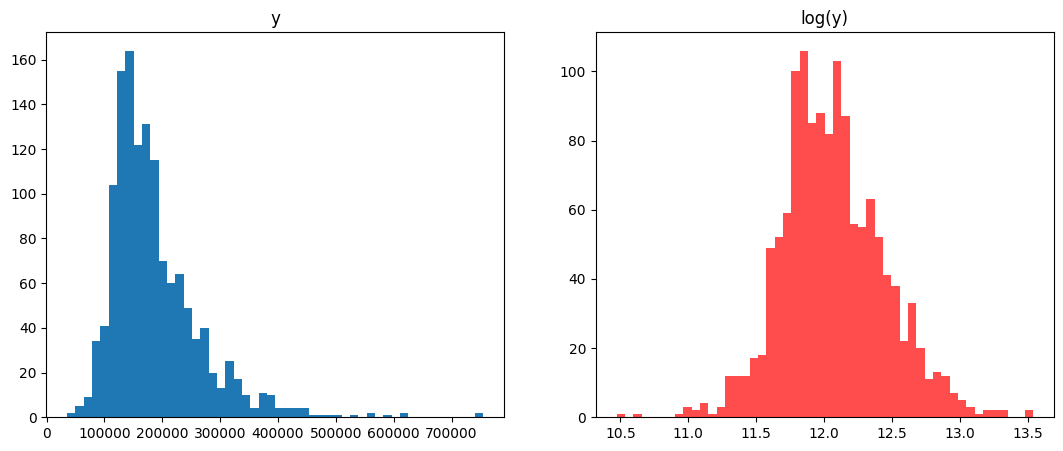

In [ ]:
plt.figure(figsize=(13,5))

plt.subplot(1, 2, 1)
plt.hist(list(y), bins=50)
plt.title('y')

plt.subplot(1, 2, 2)
y1 = np.log1p(y)
plt.hist(y1, bins=50, alpha=0.7, color='red')
plt.title('log(y)')
plt.show()

In [ ]:
results_ohe_log = fit_and_evaluate(
    X_train_ohe,
    y_train,
    models,
    cv,
    is_log=True
)

results_ohe_log['Encoding'] = 'OneHot, log'

Обучение и оценка модели: Ridge


5it [00:00, 24.61it/s]


Обучение и оценка модели: Lasso


5it [00:00, 11.75it/s]


Обучение и оценка модели: KNN


...

5it [00:00, 23.14it/s]


Обучение и оценка модели: RandomForest


5it [00:38,  7.75s/it]


Обучение и оценка модели: CatBoost


5it [00:09,  1.85s/it]


In [ ]:
results_ohe_log

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.129625,0.880470,0.017221,"OneHot, log"
4,RandomForest,0.144438,0.853867,0.021054,"OneHot, log"
1,Lasso,0.147548,0.820986,0.025353,"OneHot, log"
0,Ridge,0.162104,0.785958,0.030201,"OneHot, log"
2,KNN,0.194990,0.735909,0.038178,"OneHot, log"
3,DecisionTree,0.209212,0.690822,0.044224,"OneHot, log"


In [ ]:
results_comb_log = fit_and_evaluate(
    X_train_comb,
    y_train,
    models,
    cv,
    is_log=True
)

results_comb_log['Encoding'] = 'Ordinal + OneHot, log'

Обучение и оценка модели: Ridge


5it [00:00, 21.02it/s]


Обучение и оценка модели: Lasso


5it [00:00, 15.20it/s]


Обучение и оценка модели: KNN


...

5it [00:00, 27.53it/s]


Обучение и оценка модели: RandomForest


5it [00:34,  6.92s/it]


Обучение и оценка модели: CatBoost


5it [00:08,  1.79s/it]


In [ ]:
results_comb_log

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.124490,0.889789,0.015842,"Ordinal + OneHot, log"
1,Lasso,0.143560,0.832076,0.023823,"Ordinal + OneHot, log"
4,RandomForest,0.144448,0.853202,0.021008,"Ordinal + OneHot, log"
0,Ridge,0.153818,0.805024,0.027518,"Ordinal + OneHot, log"
2,KNN,0.200603,0.720197,0.040371,"Ordinal + OneHot, log"
3,DecisionTree,0.206489,0.694886,0.043252,"Ordinal + OneHot, log"


In [ ]:
final_results = pd.concat([results_ohe, results_comb])
final_results.sort_values(['RMSLE'])

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.127081,0.862465,9.653318e+08,Ordinal + OneHot
5,CatBoost,0.132445,0.858213,9.926946e+08,OneHot
4,RandomForest,0.144489,0.834152,1.142843e+09,Ordinal + OneHot
4,RandomForest,0.144727,0.839028,1.115636e+09,OneHot
3,DecisionTree,0.192710,0.726789,1.824609e+09,Ordinal + OneHot
2,KNN,0.192820,0.723905,1.869802e+09,OneHot
3,DecisionTree,0.198066,0.727383,1.830966e+09,OneHot
2,KNN,0.199444,0.698654,2.048515e+09,Ordinal + OneHot
0,Ridge,0.323601,0.752290,1.730536e+09,OneHot
1,Lasso,0.328737,0.745233,1.783145e+09,OneHot


In [ ]:
final_results_log = pd.concat([results_ohe_log, results_comb_log])
final_results_log.sort_values(['RMSLE'])

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.124490,0.889789,0.015842,"Ordinal + OneHot, log"
5,CatBoost,0.129625,0.880470,0.017221,"OneHot, log"
1,Lasso,0.143560,0.832076,0.023823,"Ordinal + OneHot, log"
4,RandomForest,0.144438,0.853867,0.021054,"OneHot, log"
4,RandomForest,0.144448,0.853202,0.021008,"Ordinal + OneHot, log"
1,Lasso,0.147548,0.820986,0.025353,"OneHot, log"
0,Ridge,0.153818,0.805024,0.027518,"Ordinal + OneHot, log"
0,Ridge,0.162104,0.785958,0.030201,"OneHot, log"
2,KNN,0.194990,0.735909,0.038178,"OneHot, log"
2,KNN,0.200603,0.720197,0.040371,"Ordinal + OneHot, log"


In [ ]:
overall_results = pd.concat([results_ohe, results_comb, results_ohe_log, results_comb_log])
overall_results.sort_values(['RMSLE'])

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.124490,0.889789,1.584229e-02,"Ordinal + OneHot, log"
5,CatBoost,0.127081,0.862465,9.653318e+08,Ordinal + OneHot
5,CatBoost,0.129625,0.880470,1.722119e-02,"OneHot, log"
5,CatBoost,0.132445,0.858213,9.926946e+08,OneHot
1,Lasso,0.143560,0.832076,2.382327e-02,"Ordinal + OneHot, log"
4,RandomForest,0.144438,0.853867,2.105445e-02,"OneHot, log"
4,RandomForest,0.144448,0.853202,2.100777e-02,"Ordinal + OneHot, log"
4,RandomForest,0.144489,0.834152,1.142843e+09,Ordinal + OneHot
4,RandomForest,0.144727,0.839028,1.115636e+09,OneHot
1,Lasso,0.147548,0.820986,2.535274e-02,"OneHot, log"


In [ ]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=False,
        cat_features=catagorical_columns
    )


results_catboost_log = fit_and_evaluate(
    X_train,
    y_train,
    {"CatBoost raw": catboost_model},
    cv,
    is_log=True
)

results_catboost_log['Encoding'] = 'None, CatBoost + raw catagories, log'

results_catboost = fit_and_evaluate(
    X_train,
    y_train,
    {"CatBoost raw": catboost_model},
    cv,
    is_log=True
)

results_catboost['Encoding'] = 'None, CatBoost + raw catagories'

Обучение и оценка модели: CatBoost raw


5it [01:01, 12.40s/it]


Обучение и оценка модели: CatBoost raw


5it [00:55, 11.11s/it]


In [ ]:
overall_results = pd.concat([results_ohe, results_comb,
                             results_ohe_log, results_comb_log,
                             results_catboost, results_catboost_log])
overall_results.sort_values(['RMSLE'])

,Model,RMSLE,R2,MSE,Encoding
5,CatBoost,0.124490,0.889789,1.584229e-02,"Ordinal + OneHot, log"
5,CatBoost,0.127081,0.862465,9.653318e+08,Ordinal + OneHot
5,CatBoost,0.129625,0.880470,1.722119e-02,"OneHot, log"
5,CatBoost,0.132445,0.858213,9.926946e+08,OneHot
0,CatBoost raw,0.132640,0.875282,1.791767e-02,"None, CatBoost + raw catagories"
0,CatBoost raw,0.132640,0.875282,1.791767e-02,"None, CatBoost + raw catagories, log"
1,Lasso,0.143560,0.832076,2.382327e-02,"Ordinal + OneHot, log"
4,RandomForest,0.144438,0.853867,2.105445e-02,"OneHot, log"
4,RandomForest,0.144448,0.853202,2.100777e-02,"Ordinal + OneHot, log"
4,RandomForest,0.144489,0.834152,1.142843e+09,Ordinal + OneHot
